# BAA10Y Adaptive Agent Test


In [1]:
from pathlib import Path
import json
import warnings
warnings.filterwarnings('ignore')

from BAA10Y_forecasting.adaptive_agent.tuner import (
    BAA10YTuner,
)
import pandas as pd
from IPython.display import display
from BAA10Y_forecasting.predictors.benchmark_configs import (
    NOTEBOOK_01_BENCHMARKS,
    get_benchmark_config,
)


In [2]:



def find_repo_root() -> Path:
    here = Path.cwd().resolve()
    for candidate in (here, *here.parents):
        if (candidate / 'pyproject.toml').exists() and (candidate / 'aieng-forecasting').is_dir():
            return candidate
    raise RuntimeError('Could not find repository root.')


CHECKS = []


def add_check(category: str, name: str, passed: bool, details: str = '') -> None:
    CHECKS.append(
        {
            'category': category,
            'check': name,
            'status': 'PASS' if passed else 'NOT YET',
            'details': details,
        }
    )


ROOT = find_repo_root()
STATE_PATH = (
    ROOT
    / 'implementations'
    / 'BAA10Y_forecasting'
    / 'adaptive_agent'
    / 'state'
    / 'tuning_state.yaml'
)

add_check('technical', 'Repository root found', ROOT.exists(), str(ROOT))
print('STATE_PATH:', STATE_PATH)

STATE_PATH: /home/coder/agentic-forecasting/implementations/BAA10Y_forecasting/adaptive_agent/state/tuning_state.yaml


## 1. Verify modules and tools

In [3]:
from BAA10Y_forecasting.adaptive_agent.agent import build_baa10y_adaptive_config
from BAA10Y_forecasting.adaptive_agent.skill_state import TuningStateStore
from BAA10Y_forecasting.adaptive_agent.skill_tools import build_baa10y_tuning_tools
from BAA10Y_forecasting.adaptive_agent.tuner import BAA10YTuner

add_check('technical', 'Adaptive modules import', True)

TOOLS = build_baa10y_tuning_tools(state_path=STATE_PATH)
TOOL_BY_NAME = {tool.__name__: tool for tool in TOOLS}

EXPECTED_TOOLS = {
    "get_tuning_state",
    "list_tuning_candidates",
    "get_search_space",
    "run_tuning_trial",
    "run_adaptive_search",
    "compare_tuning_trials",
    "promote_tuning_candidate",
    "reject_tuning_candidate",
}

tool_names = set(TOOL_BY_NAME)
tools_ok = EXPECTED_TOOLS.issubset(tool_names)
add_check(
    "technical",
    "Adaptive tuning tools registered",
    tools_ok,
    str(sorted(tool_names)),
)
print('Connected tools:')
for name in sorted(tool_names):
    print(' -', name)

assert tools_ok, f'Missing tools: {sorted(EXPECTED_TOOLS - tool_names)}'

Connected tools:
 - compare_tuning_trials
 - get_search_space
 - get_tuning_state
 - list_tuning_candidates
 - promote_tuning_candidate
 - reject_tuning_candidate
 - run_adaptive_search
 - run_tuning_trial


## 2. Verify candidate registry

In [4]:
candidate_output = (
    TOOL_BY_NAME[
        "list_tuning_candidates"
    ]()
)

candidate_payload = json.loads(
    candidate_output
)

if (
    candidate_payload.get("status")
    != "success"
):
    raise RuntimeError(
        candidate_payload.get(
            "message",
            "Unable to load tuning candidates.",
        )
    )

candidates = candidate_payload[
    "candidates"
]

candidate_df = pd.DataFrame(
    candidates
)

if candidate_df.empty:
    raise RuntimeError(
        "Candidate registry returned no candidates."
    )


required_methods = {
    "linear_regression",
    "lightgbm",
    "llmp_sampled_trajectory",
}

methods_found = set(
    candidate_df["method"]
)

registry_ok = (
    required_methods.issubset(
        methods_found
    )
)

baseline_ok = bool(
    candidate_df
    .groupby("method")[
        "is_baseline"
    ]
    .any()
    .all()
)


add_check(
    "technical",
    "All three predictor families registered",
    registry_ok,
    str(
        sorted(
            methods_found
        )
    ),
)

add_check(
    "technical",
    "Each family has a baseline",
    baseline_ok,
)


display(
    candidate_df[
        [
            "candidate_id",
            "method",
            "description",
            "covariate_panel",
            "is_baseline",
            "params",
        ]
    ]
)


assert registry_ok, (
    "Missing predictor families: "
    f"{sorted(required_methods - methods_found)}"
)

assert baseline_ok, (
    "At least one predictor family "
    "does not have a baseline."
)

print(
    "PASS: Candidate registry contains "
    "all three predictor families and baselines."
)

,candidate_id,method,description,covariate_panel,is_baseline,params
0,linreg_l5_target,linear_regression,Baseline: 5 target lags,target_only,True,"{'lags': 5, 'num_samples': 100}"
1,linreg_l10_target,linear_regression,10 target lags,target_only,False,"{'lags': 10, 'num_samples': 100}"
2,linreg_l5_cov,linear_regression,5 target and covariate lags,default,False,"{'lags': 5, 'lags_past_covariates': 5, 'num_sa..."
3,lightgbm_l5_target,lightgbm,Baseline: 5 target lags,target_only,True,"{'lags': 5, 'num_samples': 100, 'lgbm_kwargs':..."
4,lightgbm_l5_cov,lightgbm,5 target and covariate lags,default,False,"{'lags': 5, 'lags_past_covariates': 5, 'num_sa..."
5,lightgbm_l10_cov_tuned,lightgbm,Tuned LightGBM with 10 lags and covariates,default,False,"{'lags': 10, 'lags_past_covariates': 10, 'num_..."
6,llmp_n8_h48_target,llmp_sampled_trajectory,Baseline: 8 samples and 48-day history,target_only,True,"{'n_samples': 8, 'history_window': 48}"
7,llmp_n12_h48_target,llmp_sampled_trajectory,Increase trajectory samples from 8 to 12,target_only,False,"{'n_samples': 12, 'history_window': 48}"
8,llmp_n8_h64_target,llmp_sampled_trajectory,Increase history window from 48 to 64,target_only,False,"{'n_samples': 8, 'history_window': 64}"
9,llmp_n8_h48_cov,llmp_sampled_trajectory,Baseline LLMP parameters with covariates,default,False,"{'n_samples': 8, 'history_window': 48}"


PASS: Candidate registry contains all three predictor families and baselines.


## Optuna adaptive-search test

This test runs the notebook 01 LightGBM benchmark and then uses Optuna TPE to
select new parameter configurations based on previously observed CRPS.

The first five trials are exploratory startup trials. Beginning with trial 5,
TPE uses the previous parameter/error history to concentrate on more promising
parts of the search space.

Smoke results are screening evidence only and cannot promote a model.

In [6]:
from BAA10Y_forecasting.adaptive_agent.optimizer import (
    BAA10YAdaptiveOptimizer,
)


OPTUNA_TEST_STATE_PATH = (
    STATE_PATH.with_name(
        "optuna_test_state.yaml"
    )
)

OPTUNA_TEST_DB_PATH = (
    STATE_PATH.with_name(
        "optuna_test.db"
    )
)

optimizer = BAA10YAdaptiveOptimizer(
    state_path=OPTUNA_TEST_STATE_PATH,
    optuna_storage_path=(
        OPTUNA_TEST_DB_PATH
    ),
)

OPTUNA_RESULT = optimizer.run_search(
    method="lightgbm",
    horizon=5,
    covariate_panel="default",
    max_trials=6,
    force_refresh=False,
)

print(
    "Study:",
    OPTUNA_RESULT["study_name"],
)
print(
    "Improvement:",
    f"{OPTUNA_RESULT['improvement_pct']:.2f}%",
)
print(
    "Decision:",
    OPTUNA_RESULT["decision"],
)

[I 2026-08-22 04:57:48,377] Using an existing study with name 'baa10y_lightgbm_default_h5_tune_2025' instead of creating a new one.
[I 2026-08-22 04:57:50,513] Trial 3 finished with value: 4.219165503030118 and parameters: {'lags': 5, 'lags_past_covariates': 21, 'tree_shape': 'unlimited_leaves15', 'subsample': 0.7, 'n_estimators': 150, 'learning_rate': 0.05757368425309993, 'min_child_samples': 40, 'reg_alpha': 0.27898772130408367, 'reg_lambda': 1.4607232426760908, 'colsample_bytree': 1.0}. Best is trial 0 with value: 4.219165503030118.
[I 2026-08-22 04:57:52,789] Trial 4 finished with value: 4.267153195210196 and parameters: {'lags': 10, 'lags_past_covariates': 21, 'tree_shape': 'depth3_leaves7', 'subsample': 1.0, 'n_estimators': 50, 'learning_rate': 0.12495137958834718, 'min_child_samples': 20, 'reg_alpha': 1.0401360423556216, 'reg_lambda': 2.7335513967163982, 'colsample_bytree': 0.85}. Best is trial 0 with value: 4.219165503030118.
[I 2026-08-22 05:16:21,208] Trial 5 finished with va

Study: baa10y_lightgbm_default_h5_tune_2025
Improvement: 16.76%
Decision: advance_best_candidate_to_validate_2025


,trial_number,phase,candidate_id,mean_crps,improvement_pct
0,-1,benchmark,lightgbm_default_ef942949340b,5.0689,+0.00%
1,0,startup exploration,lightgbm_default_768b502cac6b,4.2192,+16.76%
2,1,startup exploration,lightgbm_default_be1d37a0c34d,4.2672,+15.82%
3,5,TPE learned search,lightgbm_default_4444eaa2115a,4.4064,+13.07%
4,6,TPE learned search,lightgbm_default_efc88c42eeb1,4.4294,+12.61%


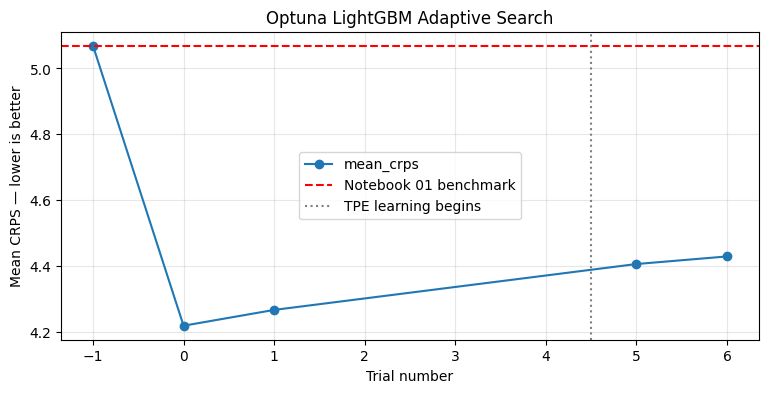

In [7]:
OPTUNA_HISTORY = pd.DataFrame(
    OPTUNA_RESULT["trial_history"]
)

OPTUNA_HISTORY["phase"] = (
    OPTUNA_HISTORY["trial_number"].apply(
        lambda number: (
            "benchmark"
            if number == -1
            else (
                "startup exploration"
                if number < 5
                else "TPE learned search"
            )
        )
    )
)

baseline_crps = float(
    OPTUNA_RESULT[
        "baseline"
    ]["mean_crps"]
)

OPTUNA_HISTORY[
    "improvement_pct"
] = (
    100.0
    * (
        baseline_crps
        - OPTUNA_HISTORY["mean_crps"]
    )
    / baseline_crps
)

display(
    OPTUNA_HISTORY[
        [
            "trial_number",
            "phase",
            "candidate_id",
            "mean_crps",
            "improvement_pct",
        ]
    ].style.format({
        "mean_crps": "{:.4f}",
        "improvement_pct": "{:+.2f}%",
    })
)
plot_data = (
    OPTUNA_HISTORY
    .sort_values("trial_number")
)

ax = plot_data.plot(
    x="trial_number",
    y="mean_crps",
    marker="o",
    figsize=(9, 4),
    legend=False,
    title=(
        "Optuna LightGBM Adaptive Search"
    ),
)

ax.axhline(
    baseline_crps,
    color="red",
    linestyle="--",
    label="Notebook 01 benchmark",
)

ax.axvline(
    4.5,
    color="gray",
    linestyle=":",
    label="TPE learning begins",
)

ax.set_xlabel(
    "Trial number"
)
ax.set_ylabel(
    "Mean CRPS — lower is better"
)
ax.grid(
    alpha=0.3
)
ax.legend()

## Final test: adaptive-agent model versus notebook 01 benchmark

This test provides the final performance comparison.

The adaptive search uses only `tune_2025`. After parameter selection is
complete, the best configuration is frozen. The notebook 01 benchmark and the
adaptive-agent-selected LightGBM configuration are then evaluated on the
independent `validate_2025` period.

The validation period was not available to Optuna when it selected parameters.

Promotion requires at least 1% validation CRPS improvement. If tuning
improvement disappears during validation, the result is treated as possible
search-window overfitting and the benchmark is retained.

In [8]:
from BAA10Y_forecasting.adaptive_agent.skill_state import (
    TuningStateStore,
)
from BAA10Y_forecasting.adaptive_agent.tuner import (
    BAA10YTuner,
)
from BAA10Y_forecasting.predictors.benchmark_configs import (
    get_benchmark_config,
)

import json


def call_json_tool(
    tool_name: str,
    **kwargs,
):
    """Call one registered adaptive-agent tool and parse its JSON."""

    if tool_name not in TOOL_BY_NAME:
        raise KeyError(
            f"Tool {tool_name!r} is not registered. "
            f"Available tools: "
            f"{sorted(TOOL_BY_NAME)}"
        )

    raw_output = TOOL_BY_NAME[
        tool_name
    ](
        **kwargs
    )

    if not isinstance(
        raw_output,
        str,
    ):
        raise TypeError(
            f"Tool {tool_name!r} returned "
            f"{type(raw_output).__name__}, "
            "but a JSON string was expected."
        )

    try:
        payload = json.loads(
            raw_output
        )
    except json.JSONDecodeError as exc:
        raise RuntimeError(
            f"Tool {tool_name!r} returned "
            "invalid JSON:\n"
            f"{raw_output}"
        ) from exc

    return payload


print(
    "PASS: call_json_tool is defined."
)

FINAL_METHOD = "lightgbm"
FINAL_HORIZON = 5
FINAL_COVARIATE_PANEL = "default"

# Use 6 for a short demonstration.
# Use 12 for the final result.
FINAL_MAX_TRIALS = 12

FINAL_FORCE_REFRESH = False
MIN_VALIDATION_IMPROVEMENT_PCT = 1.0

print(
    "Final adaptive test:",
    FINAL_METHOD,
    f"horizon={FINAL_HORIZON}",
    f"panel={FINAL_COVARIATE_PANEL}",
)

ADAPTIVE_SEARCH_RESULT = call_json_tool(
    "run_adaptive_search",
    method=FINAL_METHOD,
    horizon=FINAL_HORIZON,
    covariate_panel=(
        FINAL_COVARIATE_PANEL
    ),
    max_trials=FINAL_MAX_TRIALS,
    force_refresh=(
        FINAL_FORCE_REFRESH
    ),
)

if (
    ADAPTIVE_SEARCH_RESULT.get(
        "status"
    )
    != "success"
):
    raise RuntimeError(
        ADAPTIVE_SEARCH_RESULT
    )

assert (
    ADAPTIVE_SEARCH_RESULT[
        "experiment"
    ]
    == "tune_2025"
)

print(
    "Study:",
    ADAPTIVE_SEARCH_RESULT[
        "study_name"
    ],
)

print(
    "Completed candidate trials:",
    ADAPTIVE_SEARCH_RESULT[
        "candidate_trials_completed"
    ],
)

print(
    "Tuning-period improvement:",
    f"{ADAPTIVE_SEARCH_RESULT['improvement_pct']:.2f}%",
)

print(
    "Tuning decision:",
    ADAPTIVE_SEARCH_RESULT[
        "decision"
    ],
)
TUNING_HISTORY = pd.DataFrame(
    ADAPTIVE_SEARCH_RESULT[
        "trial_history"
    ]
)

TUNING_HISTORY["phase"] = (
    TUNING_HISTORY[
        "trial_number"
    ].apply(
        lambda number: (
            "benchmark"
            if number == -1
            else (
                "startup exploration"
                if number < 5
                else "TPE learned search"
            )
        )
    )
)

tuning_baseline_crps = float(
    ADAPTIVE_SEARCH_RESULT[
        "baseline"
    ]["mean_crps"]
)

TUNING_HISTORY[
    "improvement_pct"
] = (
    100.0
    * (
        tuning_baseline_crps
        - TUNING_HISTORY[
            "mean_crps"
        ]
    )
    / tuning_baseline_crps
)

display(
    TUNING_HISTORY[
        [
            "trial_number",
            "phase",
            "candidate_id",
            "mean_crps",
            "improvement_pct",
        ]
    ].style.format({
        "mean_crps": "{:.4f}",
        "improvement_pct": "{:+.2f}%",
    })
)
FINAL_BENCHMARK_PARAMETERS = (
    get_benchmark_config(
        FINAL_METHOD,
        FINAL_COVARIATE_PANEL,
    )
)

FINAL_TUNED_PARAMETERS = (
    ADAPTIVE_SEARCH_RESULT[
        "best_trial"
    ]["parameters"]
)

print(
    "Benchmark parameters:"
)
display(
    FINAL_BENCHMARK_PARAMETERS
)

print(
    "Adaptive-agent-selected parameters:"
)
display(
    FINAL_TUNED_PARAMETERS
)
validation_tuner = BAA10YTuner()

VALIDATION_BENCHMARK_RESULT = (
    validation_tuner.run_parameter_trial(
        method=FINAL_METHOD,
        horizon=FINAL_HORIZON,
        covariate_panel=(
            FINAL_COVARIATE_PANEL
        ),
        parameters=(
            FINAL_BENCHMARK_PARAMETERS
        ),
        experiment="validate_2025",
        force_refresh=(
            FINAL_FORCE_REFRESH
        ),
        is_baseline=True,
    )
)

VALIDATION_TUNED_RESULT = (
    validation_tuner.run_parameter_trial(
        method=FINAL_METHOD,
        horizon=FINAL_HORIZON,
        covariate_panel=(
            FINAL_COVARIATE_PANEL
        ),
        parameters=(
            FINAL_TUNED_PARAMETERS
        ),
        experiment="validate_2025",
        force_refresh=(
            FINAL_FORCE_REFRESH
        ),
        is_baseline=False,
    )
)

print(
    "Validation benchmark CRPS:",
    f"{VALIDATION_BENCHMARK_RESULT['mean_crps']:.4f}",
)

print(
    "Validation tuned CRPS:",
    f"{VALIDATION_TUNED_RESULT['mean_crps']:.4f}",
)
validation_store = TuningStateStore(
    STATE_PATH
)

VALIDATION_STUDY_NAME = (
    ADAPTIVE_SEARCH_RESULT[
        "study_name"
    ]
    + "_validation"
)


def save_validation_result(
    result,
    *,
    trial_number,
):
    saved_result = dict(
        result
    )

    saved_result.update({
        "study_name": (
            VALIDATION_STUDY_NAME
        ),
        "trial_number": (
            trial_number
        ),
        "parameter_hash": (
            saved_result[
                "candidate_id"
            ].rsplit(
                "_",
                1,
            )[-1]
        ),
        "search_strategy": (
            "holdout_validation"
        ),
    })

    trial, added = (
        validation_store.add_trial(
            saved_result
        )
    )

    print(
        trial.candidate_id,
        "->",
        (
            "saved"
            if added
            else "already saved"
        ),
    )

    return trial


VALIDATION_BENCHMARK_TRIAL = (
    save_validation_result(
        VALIDATION_BENCHMARK_RESULT,
        trial_number=-1,
    )
)

VALIDATION_TUNED_TRIAL = (
    save_validation_result(
        VALIDATION_TUNED_RESULT,
        trial_number=(
            ADAPTIVE_SEARCH_RESULT[
                "best_trial"
            ]["trial_number"]
        ),
    )
)

PASS: call_json_tool is defined.
Final adaptive test: lightgbm horizon=5 panel=default


[I 2026-08-22 05:38:24,132] A new study created in RDB with name: baa10y_lightgbm_default_h5_tune_2025
[I 2026-08-22 05:38:26,304] Trial 0 finished with value: 4.219165503030118 and parameters: {'lags': 5, 'lags_past_covariates': 21, 'tree_shape': 'unlimited_leaves15', 'subsample': 0.7, 'n_estimators': 150, 'learning_rate': 0.05757368425309993, 'min_child_samples': 40, 'reg_alpha': 0.27898772130408367, 'reg_lambda': 1.4607232426760908, 'colsample_bytree': 1.0}. Best is trial 0 with value: 4.219165503030118.
[I 2026-08-22 05:38:28,580] Trial 1 finished with value: 4.267153195210196 and parameters: {'lags': 10, 'lags_past_covariates': 21, 'tree_shape': 'depth3_leaves7', 'subsample': 1.0, 'n_estimators': 50, 'learning_rate': 0.12495137958834718, 'min_child_samples': 20, 'reg_alpha': 1.0401360423556216, 'reg_lambda': 2.7335513967163982, 'colsample_bytree': 0.85}. Best is trial 0 with value: 4.219165503030118.
[I 2026-08-22 05:38:30,820] Trial 2 finished with value: 4.406392218492249 and pa

Study: baa10y_lightgbm_default_h5_tune_2025
Completed candidate trials: 12
Tuning-period improvement: 16.92%
Tuning decision: advance_best_candidate_to_validate_2025


,trial_number,phase,candidate_id,mean_crps,improvement_pct
0,-1,benchmark,lightgbm_default_ef942949340b,5.0689,+0.00%
1,0,startup exploration,lightgbm_default_768b502cac6b,4.2192,+16.76%
2,1,startup exploration,lightgbm_default_be1d37a0c34d,4.2672,+15.82%
3,2,startup exploration,lightgbm_default_4444eaa2115a,4.4064,+13.07%
4,3,startup exploration,lightgbm_default_3cc5ed475409,4.5053,+11.12%
5,4,startup exploration,lightgbm_default_ec688c760bfb,4.6106,+9.04%
6,5,TPE learned search,lightgbm_default_96c7b223f7b4,4.2923,+15.32%
7,6,TPE learned search,lightgbm_default_bdd17af9f3b0,4.2814,+15.54%
8,7,TPE learned search,lightgbm_default_1e08515e938b,4.3666,+13.85%
9,8,TPE learned search,lightgbm_default_f0abf0505722,4.3168,+14.84%


Benchmark parameters:


{'lags': 5,
 'lags_past_covariates': 5,
 'num_samples': 100,
 'lgbm_kwargs': {'num_threads': 1,
  'n_jobs': 1,
  'verbosity': -1,
  'random_state': 42}}

Adaptive-agent-selected parameters:


{'lags': 5,
 'lags_past_covariates': 21,
 'num_samples': 100,
 'lgbm_kwargs': {'num_threads': 1,
  'n_jobs': 1,
  'verbosity': -1,
  'random_state': 42,
  'n_estimators': 400,
  'learning_rate': 0.03539386778872719,
  'max_depth': 4,
  'num_leaves': 15,
  'min_child_samples': 40,
  'reg_alpha': 1.2529578271032324,
  'reg_lambda': 2.7004751005679695,
  'subsample': 0.85,
  'subsample_freq': 1,
  'colsample_bytree': 0.85}}

Validation benchmark CRPS: 2.3259
Validation tuned CRPS: 2.3887
lightgbm_default_ef942949340b -> saved
lightgbm_default_95ba4386c9af -> saved


In [9]:
validation_baseline_crps = float(
    VALIDATION_BENCHMARK_TRIAL.mean_crps
)

validation_tuned_crps = float(
    VALIDATION_TUNED_TRIAL.mean_crps
)

validation_improvement_pct = (
    100.0
    * (
        validation_baseline_crps
        - validation_tuned_crps
    )
    / validation_baseline_crps
)

tuning_improvement_pct = float(
    ADAPTIVE_SEARCH_RESULT[
        "improvement_pct"
    ]
)


if (
    validation_improvement_pct
    >= MIN_VALIDATION_IMPROVEMENT_PCT
):
    FINAL_DECISION = (
        "VALIDATED IMPROVEMENT"
    )

elif (
    tuning_improvement_pct > 0
    and validation_improvement_pct <= 0
):
    FINAL_DECISION = (
        "POSSIBLE SEARCH-WINDOW "
        "OVERFITTING — RETAIN BENCHMARK"
    )

else:
    FINAL_DECISION = (
        "INSUFFICIENT VALIDATION "
        "IMPROVEMENT — RETAIN BENCHMARK"
    )


FINAL_PERFORMANCE_REPORT = pd.DataFrame([
    {
        "model": (
            "Notebook 01 benchmark"
        ),
        "selection_role": "benchmark",
        "tuning_crps": (
            ADAPTIVE_SEARCH_RESULT[
                "baseline"
            ]["mean_crps"]
        ),
        "validation_crps": (
            validation_baseline_crps
        ),
        "validation_improvement_pct": (
            0.0
        ),
        "n_validation_predictions": (
            VALIDATION_BENCHMARK_TRIAL
            .n_predictions
        ),
    },
    {
        "model": (
            "Adaptive-agent-selected "
            "LightGBM"
        ),
        "selection_role": (
            "Optuna tuning winner"
        ),
        "tuning_crps": (
            ADAPTIVE_SEARCH_RESULT[
                "best_trial"
            ]["mean_crps"]
        ),
        "validation_crps": (
            validation_tuned_crps
        ),
        "validation_improvement_pct": (
            validation_improvement_pct
        ),
        "n_validation_predictions": (
            VALIDATION_TUNED_TRIAL
            .n_predictions
        ),
    },
])

display(
    FINAL_PERFORMANCE_REPORT.style.format({
        "tuning_crps": "{:.4f}",
        "validation_crps": "{:.4f}",
        "validation_improvement_pct": (
            "{:+.2f}%"
        ),
    })
)

print(
    "Tuning improvement:",
    f"{tuning_improvement_pct:+.2f}%",
)

print(
    "Validation improvement:",
    f"{validation_improvement_pct:+.2f}%",
)

print(
    "FINAL DECISION:",
    FINAL_DECISION,
)

,model,selection_role,tuning_crps,validation_crps,validation_improvement_pct,n_validation_predictions
0,Notebook 01 benchmark,benchmark,5.0689,2.3259,+0.00%,20
1,Adaptive-agent-selected LightGBM,Optuna tuning winner,4.2114,2.3887,-2.70%,20


Tuning improvement: +16.92%
Validation improvement: -2.70%
FINAL DECISION: POSSIBLE SEARCH-WINDOW OVERFITTING — RETAIN BENCHMARK


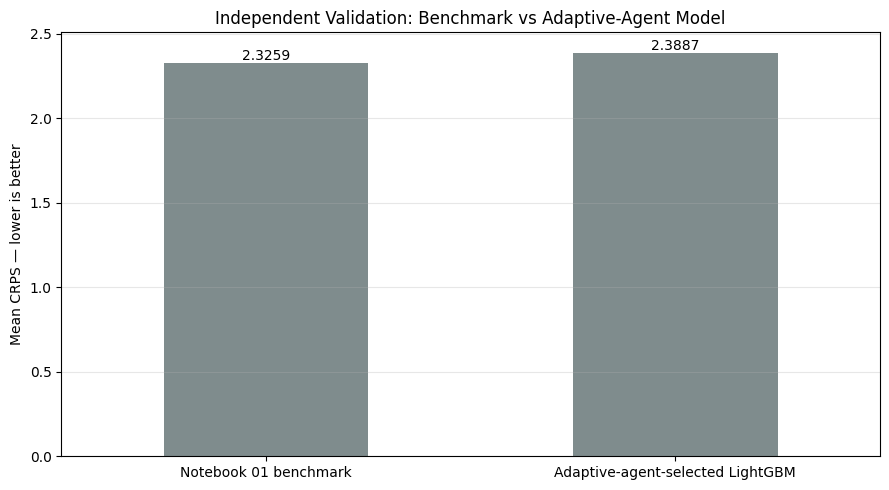

In [10]:
import matplotlib.pyplot as plt


chart_data = (
    FINAL_PERFORMANCE_REPORT[
        [
            "model",
            "validation_crps",
        ]
    ]
    .set_index("model")
)

ax = chart_data.plot(
    kind="bar",
    figsize=(9, 5),
    legend=False,
    color=[
        "#7f8c8d",
        "#2e86de",
    ],
)

ax.set_title(
    "Independent Validation: "
    "Benchmark vs Adaptive-Agent Model"
)

ax.set_xlabel("")
ax.set_ylabel(
    "Mean CRPS — lower is better"
)

ax.tick_params(
    axis="x",
    rotation=0,
)

ax.grid(
    axis="y",
    alpha=0.3,
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.4f",
    )

plt.tight_layout()
plt.show()

In [11]:
validation_test_executed = (
    VALIDATION_BENCHMARK_TRIAL
    .n_predictions
    > 0
    and VALIDATION_TUNED_TRIAL
    .n_predictions
    > 0
)

add_check(
    "technical",
    "Independent validation executed",
    validation_test_executed,
    (
        f"benchmark_predictions="
        f"{VALIDATION_BENCHMARK_TRIAL.n_predictions}; "
        f"tuned_predictions="
        f"{VALIDATION_TUNED_TRIAL.n_predictions}"
    ),
)

add_check(
    "performance",
    (
        "Adaptive LightGBM beats "
        "independent benchmark"
    ),
    (
        validation_improvement_pct
        >= MIN_VALIDATION_IMPROVEMENT_PCT
    ),
    (
        f"tuning_improvement="
        f"{tuning_improvement_pct:.2f}%; "
        f"validation_improvement="
        f"{validation_improvement_pct:.2f}%; "
        f"decision={FINAL_DECISION}"
    ),
)

FINAL_HEALTH_REPORT = pd.DataFrame(
    CHECKS
)

display(
    FINAL_HEALTH_REPORT
)

,category,check,status,details
0,technical,Repository root found,PASS,/home/coder/agentic-forecasting
1,technical,Adaptive modules import,PASS,
2,technical,Adaptive tuning tools registered,PASS,"['compare_tuning_trials', 'get_search_space', ..."
3,technical,All three predictor families registered,PASS,"['lightgbm', 'linear_regression', 'llmp_sample..."
4,technical,Each family has a baseline,PASS,
5,technical,Independent validation executed,PASS,benchmark_predictions=20; tuned_predictions=20
6,performance,Adaptive LightGBM beats independent benchmark,NOT YET,tuning_improvement=16.92%; validation_improvem...


In [12]:
from pathlib import Path

import pandas as pd
import yaml

from aieng.forecasting.evaluation import (
    MultiTargetBacktestSpec,
)


spec_path = (
    ROOT
    / "implementations"
    / "BAA10Y_forecasting"
    / "specs"
    / "baa10y_tune_2025.yaml"
)

with spec_path.open(
    encoding="utf-8"
) as file:
    tuning_spec = (
        MultiTargetBacktestSpec.model_validate(
            yaml.safe_load(file)
        )
    )

origin_dates = pd.date_range(
    start=tuning_spec.start,
    end=tuning_spec.end,
    freq="B",
)[::tuning_spec.stride]

origin_check = pd.DataFrame({
    "origin": origin_dates,
    "weekday": origin_dates.day_name(),
})

display(
    origin_check
)

assert (
    origin_check["weekday"]
    == "Wednesday"
).all()

print(
    "PASS: All tuning origins are Wednesdays."
)

,origin,weekday
0,2025-01-08,Wednesday
1,2025-01-15,Wednesday
2,2025-01-22,Wednesday
3,2025-01-29,Wednesday
4,2025-02-05,Wednesday
5,2025-02-12,Wednesday
6,2025-02-19,Wednesday
7,2025-02-26,Wednesday
8,2025-03-05,Wednesday
9,2025-03-12,Wednesday


PASS: All tuning origins are Wednesdays.
